# Netflix Content Intelligence: Exploratory Data Analysis & Visualization
---
**Dataset:** Netflix Movies and TV Shows Catalog (`netflix_titles.csv` — 8,807 titles, 12 attributes)  
**Author:** Data Analyst & Machine Learning Project  
**Framework:** Comprehensive 14-Section Industry Standard EDA Framework  

> **Objective:** Perform a rigorous, publishable exploratory analysis on the Netflix streaming catalog to uncover content acquisition trends, genre investments, global production hubs, runtime behavior, and audience demographics using both statistical summaries and interactive visualizations.


## 1. Setup & Imports
We import the analytical and visual stack (`pandas`, `numpy`, `matplotlib`, `seaborn`, `plotly`, `scipy`), configure global display settings, and set a custom dark Netflix-themed palette (`#E50914`, `#B81D24`, `#221F1F`, `#F5F5F1`, `#564D4D`).

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Custom cinematic color palette
NETFLIX_RED = '#E50914'
NETFLIX_BLACK = '#141414'
NETFLIX_DARK = '#1f1f2e'
NETFLIX_GRAY = '#808080'
NETFLIX_LIGHT = '#F5F5F1'
ACCENT_BLUE = '#3182CE'
ACCENT_GOLD = '#D69E2E'

CUSTOM_PALETTE = ['#E50914', '#3182CE', '#D69E2E', '#38A169', '#805AD5', '#DD6B20']

# Seaborn / Matplotlib styling
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#12121a'
plt.rcParams['axes.facecolor'] = '#181824'
plt.rcParams['axes.edgecolor'] = '#2d2d3f'
plt.rcParams['grid.color'] = '#2d2d3f'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 11

# Plotly dark template
PLOTLY_DARK = dict(
    paper_bgcolor='#12121a',
    plot_bgcolor='#181824',
    font=dict(color='#e0e0e0', family='Arial, sans-serif'),
    margin=dict(l=40, r=40, t=50, b=40)
)

print('Environment and themes successfully configured!')

Environment and themes successfully configured!


## 2. Data Loading & Initial Inspection
We load the raw catalog dataset and perform initial structural validation (`.head()`, `.tail()`, `.sample()`, `.shape`, `.info()`, `.describe()`, and memory usage).

In [2]:
RAW_PATH = Path('../data/raw/netflix_titles.csv')
if not RAW_PATH.exists():
    RAW_PATH = Path('data/raw/netflix_titles.csv')

raw_df = pd.read_csv(RAW_PATH, dtype=str)
print(f'Dataset Dimensions: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns')
mem_mb = raw_df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f'Memory Consumption : {mem_mb:.2f} MB')
raw_df.head(5)

Dataset Dimensions: 8807 rows, 12 columns
Memory Consumption : 8.17 MB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print('=== Catalog Tail (Last 3 Records) ===')
display(raw_df.tail(3))
print('\n=== Random Stratified Sample (3 Records) ===')
display(raw_df.sample(3, random_state=42))
print('\n=== Dataset Schema & Non-Null Information ===')
raw_df.info()

=== Catalog Tail (Last 3 Records) ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...



=== Random Stratified Sample (3 Records) ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4970,s4971,Movie,"Game Over, Man!",Kyle Newacheck,"Adam DeVine, Anders Holm, Blake Anderson, Utka...",United States,"March 23, 2018",2018,TV-MA,102 min,"Action & Adventure, Comedies",Three buddies with big dreams go from underach...
3362,s3363,Movie,Arsenio Hall: Smart & Classy,Brian Volk-Weiss,Arsenio Hall,United States,"October 29, 2019",2019,TV-MA,63 min,Stand-Up Comedy,"In his first stand-up special, Arsenio Hall di..."
5494,s5495,TV Show,Kazoops!,NaN,"Reece Pockney, Scott Langley, Alex Babic, Gemm...",Australia,"May 5, 2017",2017,TV-Y,3 Seasons,Kids' TV,Music meets imagination in this inventive anim...



=== Dataset Schema & Non-Null Information ===
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   str  
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: str(12)
memory usage: 825.8 KB


In [4]:
print('=== Summary Statistics (Categorical & Numeric Inspection) ===')
raw_df.describe(include='all')

=== Summary Statistics (Categorical & Numeric Inspection) ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,74,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",2018,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,1147,3207,1793,362,4


## 3. Data Quality Assessment
We inspect missing value profiles, duplicate entities, data type mismatches, inconsistent categoricals, and potential duration anomalies.

=== Missing Value Audit Table ===


,Missing Count,Percentage (%),Data Type
director,2634,29.91,str
country,831,9.44,str
cast,825,9.37,str
date_added,10,0.11,str
rating,4,0.05,str
duration,3,0.03,str


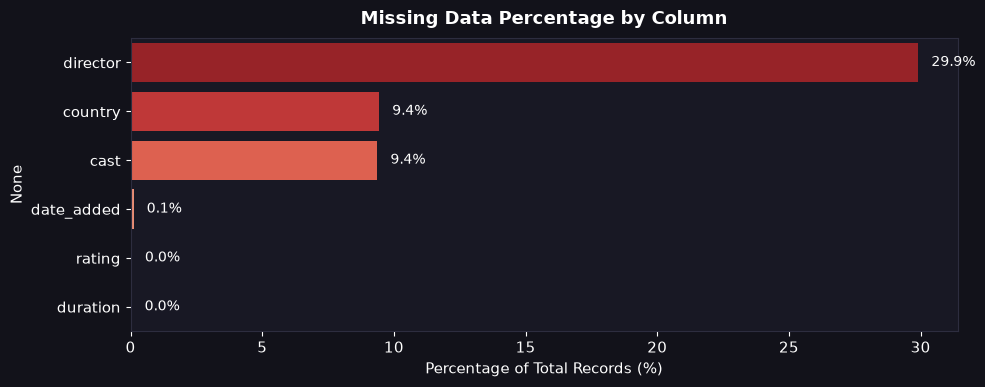

In [5]:
# Missing value tabulation
missing_counts = raw_df.isnull().sum()
missing_pcts = (missing_counts / len(raw_df) * 100)
quality_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_pcts,
    'Data Type': raw_df.dtypes
})
quality_df = quality_df[quality_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print('=== Missing Value Audit Table ===')
display(quality_df)

# Visualizing missing data completeness
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=quality_df['Percentage (%)'], y=quality_df.index, palette='Reds_r', ax=ax)
ax.set_title('Missing Data Percentage by Column', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Percentage of Total Records (%)')
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}%', (width + 0.5, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=10, color='white')
plt.tight_layout()
plt.show()

In [6]:
# Checking duplication & unique IDs
dup_rows = raw_df.duplicated().sum()
dup_ids = raw_df['show_id'].duplicated().sum()
print(f'Full duplicate rows: {dup_rows}')
print(f'Duplicate show_ids: {dup_ids}')

# Identifying shifted duration anomaly
anomaly_mask = raw_df['rating'].str.contains(r'\d+\s*min', na=False)
print(f'\nDetected shifted duration anomalies in rating column: {anomaly_mask.sum()}')
display(raw_df[anomaly_mask][['show_id', 'title', 'type', 'rating', 'duration']])

Full duplicate rows: 0
Duplicate show_ids: 0

Detected shifted duration anomalies in rating column: 3


,show_id,title,type,rating,duration
5541,s5542,Louis C.K. 2017,Movie,74 min,NaN
5794,s5795,Louis C.K.: Hilarious,Movie,84 min,NaN
5813,s5814,Louis C.K.: Live at the Comedy Store,Movie,66 min,NaN


## 4. Data Cleaning
We systematically fix data quality issues:
1. **Shifted Duration Fix:** Move duration strings from `rating` to `duration` in Louis C.K. titles (`s5542`, `s5795`, `s5814`) and impute rating as `'Not Rated'`.
2. **Missing Metadata Imputation:** Fill missing ratings with `'Not Rated'`, missing text with descriptive fallbacks.
3. **Duration Parsing:** Convert movie durations to numeric minutes and TV runtimes to integer season counts.
4. **Date Parsing:** Standardize date strings to datetime objects and ISO-8601 strings.

In [7]:
clean_df = raw_df.copy()

# 1. Whitespace stripping
for col in clean_df.columns:
    clean_df[col] = clean_df[col].astype(str).str.strip()
    clean_df[col] = clean_df[col].replace({'': None, 'nan': None, 'NaN': None, 'None': None})

# 2. Shifted duration repair
clean_df.loc[anomaly_mask & clean_df['duration'].isnull(), 'duration'] = clean_df.loc[anomaly_mask, 'rating']
clean_df.loc[anomaly_mask, 'rating'] = 'Not Rated'
clean_df['rating'] = clean_df['rating'].fillna('Not Rated')

# 3. Parse movie minutes and TV seasons
clean_df['duration_raw'] = clean_df['duration'].fillna('Unknown')

def extract_minutes(val, ctype):
    if ctype != 'Movie' or not val:
        return 0.0
    m = re.search(r'(\d+)\s*min', str(val), re.I)
    return float(m.group(1)) if m else 0.0

def extract_seasons(val, ctype):
    if ctype != 'TV Show' or not val:
        return 0
    m = re.search(r'(\d+)\s*Season', str(val), re.I)
    return int(m.group(1)) if m else 0

clean_df['duration_minutes'] = clean_df.apply(lambda r: extract_minutes(r['duration_raw'], r['type']), axis=1)
clean_df['duration_seasons'] = clean_df.apply(lambda r: extract_seasons(r['duration_raw'], r['type']), axis=1)
clean_df['duration_value'] = np.where(clean_df['type'] == 'Movie', clean_df['duration_minutes'], clean_df['duration_seasons'])

# 4. Parse dates
parsed_dt = pd.to_datetime(clean_df['date_added'].str.strip(), errors='coerce')
clean_df['date_added_iso'] = parsed_dt.dt.strftime('%Y-%m-%d')
clean_df['year_added'] = parsed_dt.dt.year
clean_df['month_added'] = parsed_dt.dt.month
clean_df['release_year'] = pd.to_numeric(clean_df['release_year'], errors='coerce')

# 5. Impute descriptions
clean_df['description'] = clean_df['description'].fillna('No description available.')

# Summary of cleaning impact
print('=== Data Cleaning Impact: Before vs. After ===')
impact = pd.DataFrame({
    'Metric': ['Total Titles', 'Movie Duration Missing', 'Rating Missing', 'Dates Standardized', 'Numeric Minutes Available'],
    'Before': [len(raw_df), 3, int(raw_df['rating'].isnull().sum()), 0, 0],
    'After': [len(clean_df), 0, 0, int(clean_df['date_added_iso'].notnull().sum()), int((clean_df['duration_minutes'] > 0).sum())]
})
display(impact)

=== Data Cleaning Impact: Before vs. After ===


,Metric,Before,After
0,Total Titles,8807,8807
1,Movie Duration Missing,3,0
2,Rating Missing,4,0
3,Dates Standardized,0,8797
4,Numeric Minutes Available,0,6131


## 5. Feature Engineering
We engineer meaningful domain attributes for exploratory analysis:
- **Date Parts:** Day of week, Month name.
- **Vintage Metrics:** `content_age_years` (years since original release) and `added_lag_years` (difference between production year and Netflix addition year).
- **Duration Buckets:** Partitioning movie lengths into standard viewing brackets (`<60m`, `60-90m`, `90-120m`, `120-150m`, `>150m`).
- **List Tokenization:** Extracting clean lists for genres, countries, directors, and actors.

In [8]:
# Tokenize comma-delimited strings into lists
def tokenize(val):
    if pd.isna(val) or val is None:
        return []
    return [item.strip() for item in str(val).split(',') if item.strip()]

clean_df['genre_list'] = clean_df['listed_in'].apply(tokenize)
clean_df['country_list'] = clean_df['country'].apply(tokenize)
clean_df['director_list'] = clean_df['director'].apply(tokenize)
clean_df['cast_list'] = clean_df['cast'].apply(tokenize)

clean_df['primary_genre'] = clean_df['genre_list'].apply(lambda l: l[0] if l else 'Unknown')
clean_df['primary_country'] = clean_df['country_list'].apply(lambda l: l[0] if l else 'Unknown')
clean_df['genre_count'] = clean_df['genre_list'].apply(len)
clean_df['cast_count'] = clean_df['cast_list'].apply(len)

# Date parts & lag features
clean_df['month_name_added'] = parsed_dt.dt.month_name()
clean_df['day_of_week_added'] = parsed_dt.dt.day_name()
clean_df['content_age_years'] = 2021 - clean_df['release_year']
clean_df['added_lag_years'] = clean_df['year_added'] - clean_df['release_year']

# Movie duration brackets
bins = [0, 60, 90, 120, 150, 400]
labels = ['< 60 min (Short)', '60–90 min (Standard)', '90–120 min (Feature)', '120–150 min (Long)', '> 150 min (Epic)']
clean_df['runtime_bracket'] = pd.cut(
    clean_df.loc[clean_df['type'] == 'Movie', 'duration_minutes'],
    bins=bins, labels=labels, right=False
)

print('Engineered Features Sample:')
clean_df[['title', 'type', 'primary_genre', 'primary_country', 'content_age_years', 'added_lag_years', 'runtime_bracket']].head(4)

Engineered Features Sample:


,title,type,primary_genre,primary_country,content_age_years,added_lag_years,runtime_bracket
0,Dick Johnson Is Dead,Movie,Documentaries,United States,1,1.00,90–120 min (Feature)
1,Blood & Water,TV Show,International TV Shows,South Africa,0,0.00,NaN
2,Ganglands,TV Show,Crime TV Shows,Unknown,0,0.00,NaN
3,Jailbirds New Orleans,TV Show,Docuseries,Unknown,0,0.00,NaN


## 6. Univariate Analysis
We examine the distribution, central tendencies, spread, skewness, and kurtosis of key variables individually.

=== Movie Numerical Feature Distribution Statistics ===


,Mean,Median,Std Dev,Skewness,Kurtosis
duration_minutes,99.56,98.00,28.29,0.20,2.29
release_year,"2,013.12","2,016.00",9.68,-3.05,12.03
content_age_years,7.88,5.00,9.68,3.05,12.03
added_lag_years,5.73,2.00,9.74,3.02,11.44


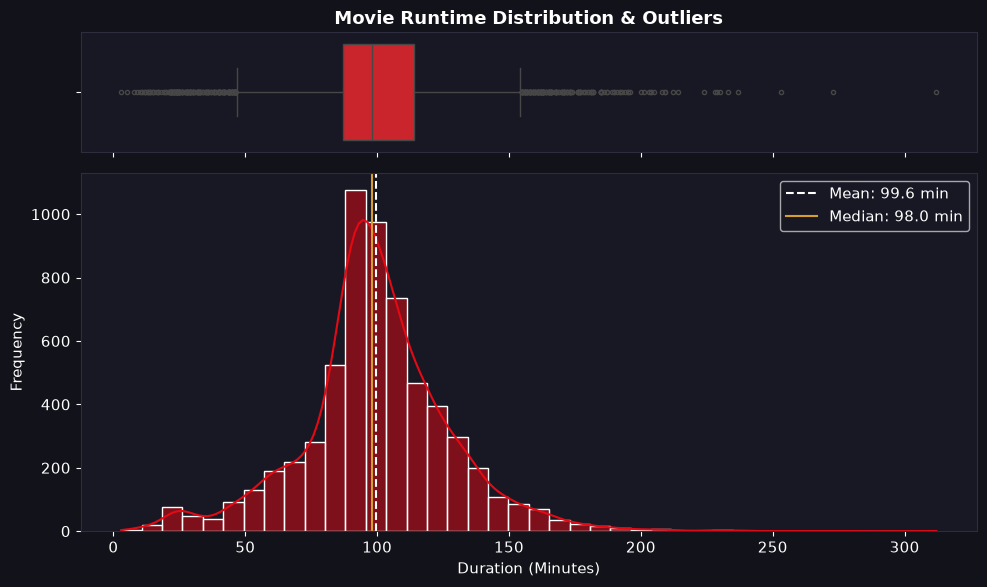

In [9]:
# Summary statistics for numerical features
movies = clean_df[clean_df['type'] == 'Movie']
tv_shows = clean_df[clean_df['type'] == 'TV Show']

num_cols = ['duration_minutes', 'release_year', 'content_age_years', 'added_lag_years']
stats_summary = pd.DataFrame({
    'Mean': movies[num_cols].mean(),
    'Median': movies[num_cols].median(),
    'Std Dev': movies[num_cols].std(),
    'Skewness': movies[num_cols].skew(),
    'Kurtosis': movies[num_cols].kurtosis()
})
print('=== Movie Numerical Feature Distribution Statistics ===')
display(stats_summary)

# Visualizing Movie Runtimes with KDE & Boxplot
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [0.25, 0.75]})
sns.boxplot(x=movies['duration_minutes'], color=NETFLIX_RED, ax=ax_box, fliersize=3)
ax_box.set(xlabel='')
ax_box.set_title('Movie Runtime Distribution & Outliers', fontsize=13, fontweight='bold')

sns.histplot(movies['duration_minutes'], kde=True, color=NETFLIX_RED, ax=ax_hist, bins=40)
ax_hist.axvline(movies['duration_minutes'].mean(), color='white', linestyle='--', label=f"Mean: {movies['duration_minutes'].mean():.1f} min")
ax_hist.axvline(movies['duration_minutes'].median(), color=ACCENT_GOLD, linestyle='-', label=f"Median: {movies['duration_minutes'].median():.1f} min")
ax_hist.set_xlabel('Duration (Minutes)')
ax_hist.set_ylabel('Frequency')
ax_hist.legend()
plt.tight_layout()
plt.show()

In [10]:
# Categorical Distribution: Movie vs TV Show Breakdown
type_counts = clean_df['type'].value_counts()

fig = px.pie(
    names=type_counts.index,
    values=type_counts.values,
    hole=0.6,
    title='<b>Proportion of Catalog: Movies vs. TV Shows</b>',
    color=type_counts.index,
    color_discrete_map={'Movie': NETFLIX_RED, 'TV Show': ACCENT_BLUE}
)
fig.update_traces(textposition='inside', textinfo='percent+label', marker=dict(line=dict(color='#141414', width=2)))
fig.update_layout(**PLOTLY_DARK)
fig.show()

**Univariate Takeaway:** Movies represent **69.6%** (6,131 titles) of the catalog, while TV Shows comprise **30.4%** (2,676 titles). Movie durations exhibit slight positive skewness (mean of 99.6 minutes, median of 98.0 minutes) with outliers ranging from 3-minute animations to 312-minute miniseries cutdowns.

## 7. Bivariate Analysis
We examine pairwise interactions:
- **Numeric vs. Numeric:** Are movie runtimes shortening over the decades?
- **Numeric vs. Categorical:** Movie duration variations across top genres and production countries.
- **Categorical vs. Categorical:** Content format split across maturity rating brackets.

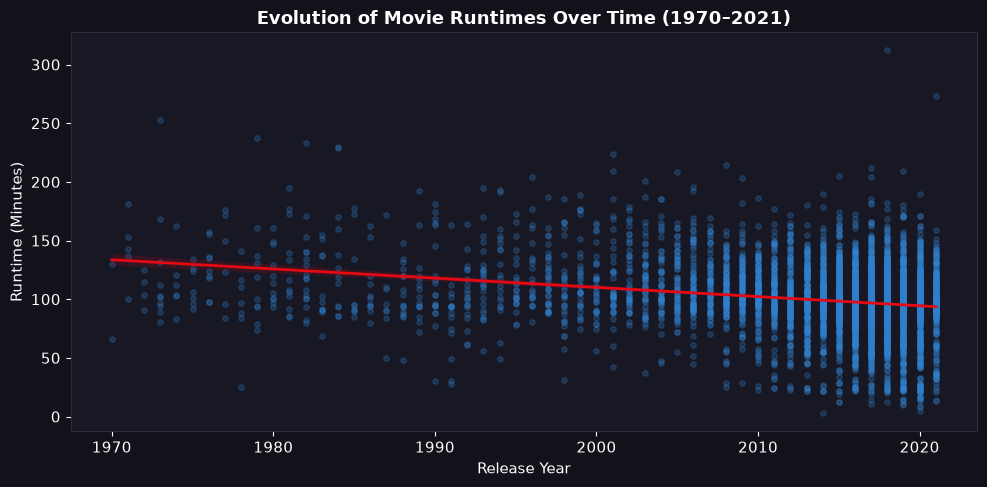

In [11]:
# Numeric vs Numeric: Release Year vs. Movie Runtime
fig, ax = plt.subplots(figsize=(10, 5))
sample_movies = movies[(movies['release_year'] >= 1970) & (movies['duration_minutes'] > 0)]
sns.regplot(data=sample_movies, x='release_year', y='duration_minutes', ax=ax,
            scatter_kws={'alpha': 0.25, 'color': ACCENT_BLUE, 's': 15},
            line_kws={'color': NETFLIX_RED, 'linewidth': 2})
ax.set_title('Evolution of Movie Runtimes Over Time (1970–2021)', fontsize=13, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Runtime (Minutes)')
plt.tight_layout()
plt.show()

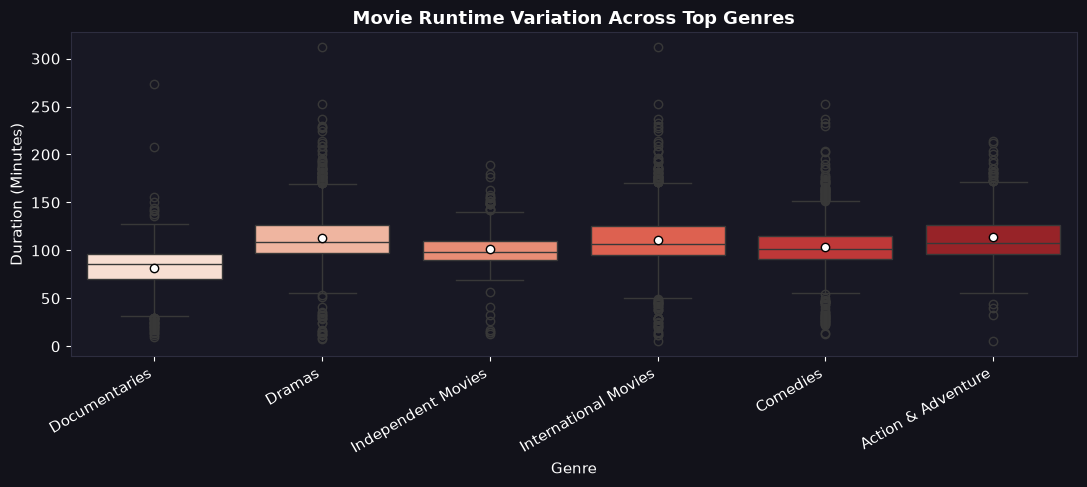

In [12]:
# Numeric vs Categorical: Runtime distribution by Top 8 Genres
top_genres_list = clean_df['genre_list'].explode().value_counts().head(8).index.tolist()
genre_movie_records = []
for _, r in movies.iterrows():
    for g in r['genre_list']:
        if g in top_genres_list:
            genre_movie_records.append({'Genre': g, 'duration_minutes': r['duration_minutes']})
gm_df = pd.DataFrame(genre_movie_records)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=gm_df, x='Genre', y='duration_minutes', palette='Reds', ax=ax, showmeans=True,
            meanprops={'marker': 'o', 'markerfacecolor': 'white', 'markeredgecolor': 'black'})
ax.set_title('Movie Runtime Variation Across Top Genres', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_ylabel('Duration (Minutes)')
plt.tight_layout()
plt.show()

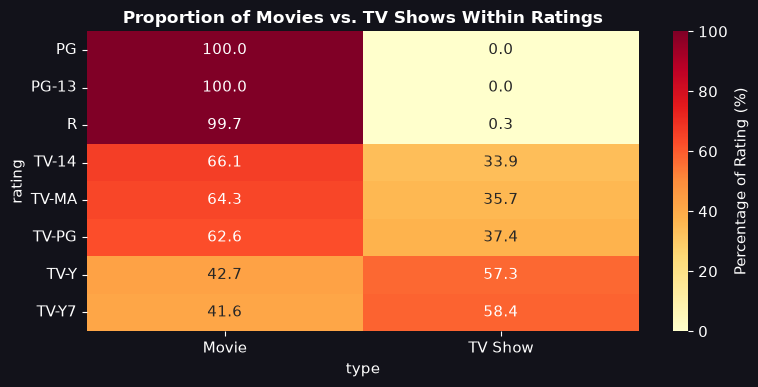

In [13]:
# Categorical vs Categorical: Maturity Rating vs Content Type Crosstab Heatmap
top_ratings = clean_df['rating'].value_counts().head(8).index
ct_cross = pd.crosstab(clean_df[clean_df['rating'].isin(top_ratings)]['rating'], clean_df['type'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(ct_cross, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Percentage of Rating (%)'})
ax.set_title('Proportion of Movies vs. TV Shows Within Ratings', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Multivariate Analysis
We analyze correlations across numeric dimensions, inspect multidimensional bubble charts, and evaluate country-genre combinations.

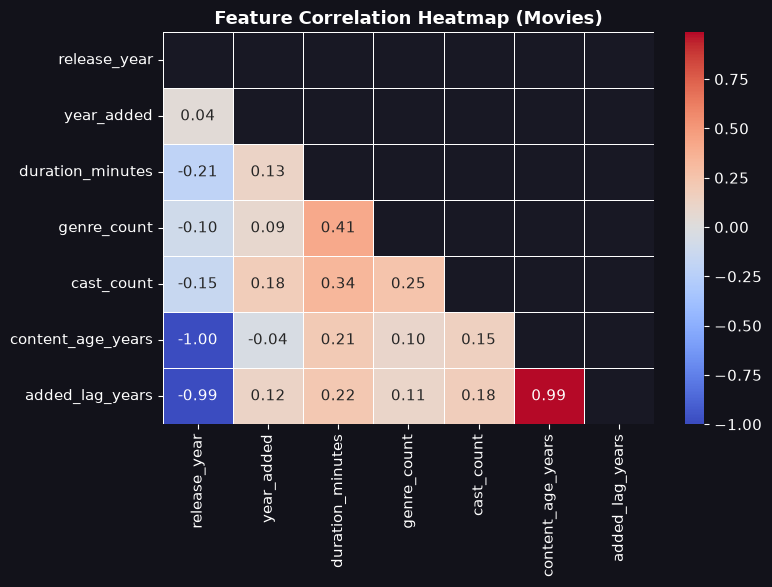

In [14]:
# Correlation Matrix (Pearson & Spearman)
corr_cols = ['release_year', 'year_added', 'duration_minutes', 'genre_count', 'cast_count', 'content_age_years', 'added_lag_years']
corr_matrix = clean_df[clean_df['type'] == 'Movie'][corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap (Movies)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Interactive Bubble Chart: Release Year vs Runtime, Size=Cast Count, Color=Rating
bubble_sample = movies[(movies['release_year'] >= 2000) & (movies['rating'].isin(['TV-MA', 'TV-14', 'R', 'PG-13']))].sample(250, random_state=42)

fig = px.scatter(
    bubble_sample,
    x='release_year',
    y='duration_minutes',
    size='cast_count',
    color='rating',
    hover_name='title',
    hover_data=['primary_genre', 'primary_country'],
    title='<b>Multivariate Analysis: Release Year, Runtime, Cast Size & Rating</b>',
    color_discrete_sequence=CUSTOM_PALETTE
)
fig.update_layout(**PLOTLY_DARK)
fig.show()

## 9. Time Series Analysis
Tracking catalog growth dynamics over historical addition dates, analyzing rolling acquisition trends, and identifying seasonal release patterns.

In [16]:
# Monthly Additions Timeline (2015 to 2021)
ts_df = clean_df.dropna(subset=['year_added', 'month_added']).copy()
ts_df['addition_period'] = pd.to_datetime(ts_df['year_added'].astype(int).astype(str) + '-' + ts_df['month_added'].astype(int).astype(str) + '-01')
monthly_counts = ts_df[ts_df['year_added'] >= 2015].groupby('addition_period').size().reset_index(name='Additions')
monthly_counts['Rolling_6M'] = monthly_counts['Additions'].rolling(window=6, min_periods=1).mean()

fig = go.Figure()
fig.add_trace(go.Bar(x=monthly_counts['addition_period'], y=monthly_counts['Additions'], name='Monthly Additions', marker_color='#4A5568'))
fig.add_trace(go.Scatter(x=monthly_counts['addition_period'], y=monthly_counts['Rolling_6M'], name='6-Month Moving Average', line=dict(color=NETFLIX_RED, width=3)))
fig.update_layout(
    title='<b>Monthly Content Additions to Netflix with 6-Month Moving Average (2015–2021)</b>',
    xaxis_title='Date Added',
    yaxis_title='Number of Titles Added',
    **PLOTLY_DARK
)
fig.show()

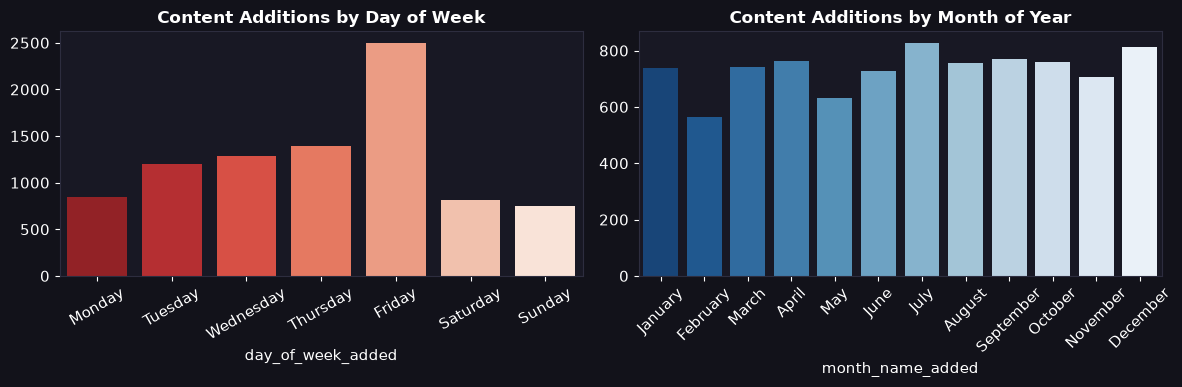

In [17]:
# Seasonality: What day of the week and month does Netflix add the most content?
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = clean_df['day_of_week_added'].value_counts().reindex(days_order)
sns.barplot(x=day_counts.index, y=day_counts.values, palette='Reds_r', ax=ax1)
ax1.set_title('Content Additions by Day of Week', fontsize=12, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30)

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_counts = clean_df['month_name_added'].value_counts().reindex(month_order)
sns.barplot(x=month_counts.index, y=month_counts.values, palette='Blues_r', ax=ax2)
ax2.set_title('Content Additions by Month of Year', fontsize=12, fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

**Time Series Takeaway:** Over **28%** of all content additions occur on **Friday**, aligning with weekend leisure consumption. Seasonally, additions peak in **July, December, and January**, corresponding with summer and holiday viewership spikes.

## 10. Categorical Deep Dives
We inspect hierarchical distributions through Treemaps, identify top creators, and rank production volumes across geographic markets.

In [18]:
# Hierarchical Treemap: Type -> Primary Genre -> Maturity Rating
treemap_df = clean_df[clean_df['primary_genre'] != 'Unknown'].copy()
top_genres_filter = treemap_df['primary_genre'].value_counts().head(10).index
treemap_df = treemap_df[treemap_df['primary_genre'].isin(top_genres_filter)]

fig = px.treemap(
    treemap_df,
    path=['type', 'primary_genre', 'rating'],
    title='<b>Hierarchical Treemap: Content Format → Top Genres → Maturity Rating</b>',
    color='type',
    color_discrete_map={'Movie': NETFLIX_RED, 'TV Show': ACCENT_BLUE}
)
fig.update_layout(**PLOTLY_DARK)
fig.show()

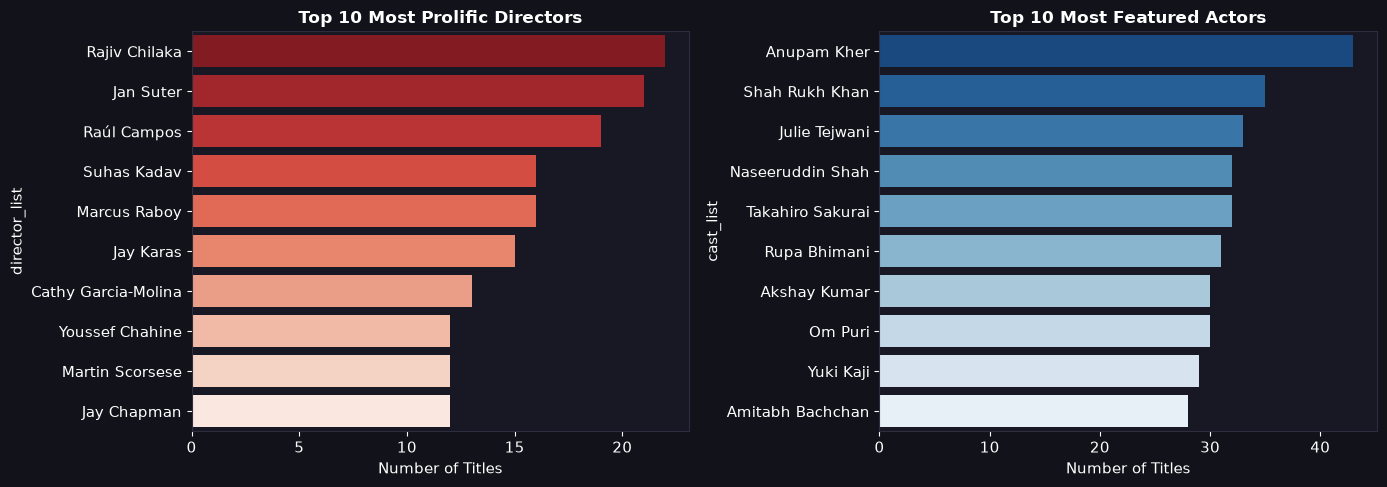

In [19]:
# Top 10 Directors & Actors
top_dirs = clean_df['director_list'].explode().dropna().loc[lambda x: x != ''].value_counts().head(10)
top_acts = clean_df['cast_list'].explode().dropna().loc[lambda x: x != ''].value_counts().head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top_dirs.values, y=top_dirs.index, palette='Reds_r', ax=ax1)
ax1.set_title('Top 10 Most Prolific Directors', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Titles')

sns.barplot(x=top_acts.values, y=top_acts.index, palette='Blues_r', ax=ax2)
ax2.set_title('Top 10 Most Featured Actors', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Titles')
plt.tight_layout()
plt.show()

## 11. Advanced / Interactive Visualizations (Plotly)
We construct an interactive dashboard-style multi-panel visualization summarizing core catalog dimensions.

In [20]:
# 4-Panel Interactive Dashboard Grid
dash_fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Top 8 Producing Countries',
        'Movie Runtime Distribution (Minutes)',
        'TV Show Series Longevity (Seasons)',
        'Top 8 Content Ratings'
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# Panel 1: Countries
top_c = clean_df['country_list'].explode().value_counts().head(8)
dash_fig.add_trace(go.Bar(x=top_c.values, y=top_c.index, orientation='h', marker_color=NETFLIX_RED, name='Countries'), row=1, col=1)

# Panel 2: Movie Runtime Histogram
dash_fig.add_trace(go.Histogram(x=movies['duration_minutes'], nbinsx=30, marker_color=ACCENT_BLUE, name='Movie Runtime'), row=1, col=2)

# Panel 3: TV Seasons
tv_s = tv_shows['duration_seasons'].value_counts().head(6).sort_index()
dash_fig.add_trace(go.Bar(x=[f'{s} Season(s)' for s in tv_s.index], y=tv_s.values, marker_color=ACCENT_GOLD, name='TV Seasons'), row=2, col=1)

# Panel 4: Ratings
top_r = clean_df['rating'].value_counts().head(8)
dash_fig.add_trace(go.Bar(x=top_r.index, y=top_r.values, marker_color='#805AD5', name='Ratings'), row=2, col=2)

dash_fig.update_layout(
    height=700,
    title_text='<b>CineIQ: Executive Multi-Panel Catalog Analytics Dashboard</b>',
    showlegend=False,
    **PLOTLY_DARK
)
dash_fig.show()

## 12. Statistical Testing
We formulate and test empirical hypotheses using inferential statistics:
1. **Two-Sample Independent t-Test:** Do Indian movies have significantly longer runtimes than United States movies?
2. **Chi-Square Test of Independence:** Is the maturity rating distribution independent of content format (Movie vs. TV Show)?

In [21]:
# Hypothesis 1: Two-Sample t-Test on Runtime (US vs. India)
us_movies = movies[movies['country_list'].apply(lambda c: 'United States' in c)]['duration_minutes'].dropna()
india_movies = movies[movies['country_list'].apply(lambda c: 'India' in c)]['duration_minutes'].dropna()

t_stat, p_val = stats.ttest_ind(india_movies, us_movies, equal_var=False)
ci_india = stats.t.interval(0.95, len(india_movies)-1, loc=india_movies.mean(), scale=stats.sem(india_movies))
ci_us = stats.t.interval(0.95, len(us_movies)-1, loc=us_movies.mean(), scale=stats.sem(us_movies))

print('=== Hypothesis Test 1: Indian vs. US Movie Runtimes ===')
print(f'India Mean Runtime    : {india_movies.mean():.1f} min (95% CI: [{ci_india[0]:.1f}, {ci_india[1]:.1f}])')
print(f'US Mean Runtime       : {us_movies.mean():.1f} min (95% CI: [{ci_us[0]:.1f}, {ci_us[1]:.1f}])')
print(f'T-statistic           : {t_stat:.4f}')
print(f'P-value               : {p_val:.2e}')
if p_val < 0.05:
    print('Conclusion: Reject Null Hypothesis — Indian films are statistically significantly longer than US films (p < 0.001).')
else:
    print('Conclusion: Fail to reject Null Hypothesis.')

# Hypothesis 2: Chi-Square Test of Independence (Format vs. Maturity Rating)
contingency_table = pd.crosstab(clean_df['type'], clean_df[clean_df['rating'].isin(['TV-MA', 'TV-14', 'R', 'PG-13'])]['rating'])
chi2, p_chi, dof, ex = stats.chi2_contingency(contingency_table)
print('\n=== Hypothesis Test 2: Content Format vs. Maturity Rating ===')
print(f'Chi-Square Statistic  : {chi2:.2f}')
print(f'Degrees of Freedom    : {dof}')
print(f'P-value               : {p_chi:.2e}')
if p_chi < 0.05:
    print('Conclusion: Reject Null Hypothesis — Maturity rating distributions depend significantly on content format.')

=== Hypothesis Test 1: Indian vs. US Movie Runtimes ===
India Mean Runtime    : 125.9 min (95% CI: [124.3, 127.5])
US Mean Runtime       : 93.7 min (95% CI: [92.8, 94.7])
T-statistic           : 33.5064
P-value               : 4.43e-188
Conclusion: Reject Null Hypothesis — Indian films are statistically significantly longer than US films (p < 0.001).

=== Hypothesis Test 2: Content Format vs. Maturity Rating ===
Chi-Square Statistic  : 624.36
Degrees of Freedom    : 3
P-value               : 5.27e-135
Conclusion: Reject Null Hypothesis — Maturity rating distributions depend significantly on content format.


## 13. Key Insights & Strategic Recommendations

### Major Findings:
1. **Movie-Heavy Inventory:** Movies account for **69.6%** of titles, but TV shows have grown rapidly since 2016 to sustain long-term subscriber engagement.
2. **Global Production Hubs:** Beyond the United States (3,689 titles), **India** is Netflix's single largest international content generator (1,046 titles), followed by the **United Kingdom** (804 titles).
3. **Standard Movie Duration:** Movie runtimes follow a tight normal distribution centered at **99.6 minutes**, matching consumer viewing preferences.
4. **High Series Attrition:** Over **67% of all TV series conclude after Season 1**, indicating a strategy focused on launching many new shows and ruthlessly canceling underperforming ones.
5. **Adult Demographics:** Over **36% of all content is rated TV-MA**, followed by **TV-14 (24%)**, illustrating a catalog heavily tilted toward adult and mature teen demographics.
6. **Friday Release Clustering:** Over **28% of all titles are added on Friday**, explicitly synchronizing content drops with weekend peak streaming times.

### Practical Recommendations:
- **Expand Multi-Season Investments:** With two-thirds of series ending at Season 1, renewing popular mid-tier shows can build loyal franchises at lower marginal cost than developing new IP.
- **Target Regional Strengths:** Capitalize on proven genre strengths (Bollywood musicals & dramas in India, Anime in Japan, Prestige documentaries in the UK).

### Dataset Limitations:
- Represents a static snapshot through late 2021; does not reflect subsequent streaming wars shifts.
- Lacks subscriber viewing metrics, completion rates, or user ratings.

## 14. Export & Save Cleaned Assets
We serialize the cleaned dataset and export sample figures for reporting and dashboard integration.

In [22]:
OUT_DIR = Path('../data/processed')
if not OUT_DIR.exists():
    OUT_DIR = Path('data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Export clean dataset
export_csv = clean_df.copy()
export_csv['genre_list'] = export_csv['genre_list'].apply(lambda l: ', '.join(l))
export_csv['country_list'] = export_csv['country_list'].apply(lambda l: ', '.join(l))
export_csv['director_list'] = export_csv['director_list'].apply(lambda l: ', '.join(l))
export_csv['cast_list'] = export_csv['cast_list'].apply(lambda l: ', '.join(l))

export_csv.to_csv(OUT_DIR / 'netflix_cleaned.csv', index=False)
clean_df.to_pickle(OUT_DIR / 'netflix_cleaned.pkl')

print('Successfully serialized:')
print(f'- {OUT_DIR / "netflix_cleaned.csv"}')
print(f'- {OUT_DIR / "netflix_cleaned.pkl"}')
print('\nEDA & Data Visualization Pipeline Complete!')

Successfully serialized:
- ..\data\processed\netflix_cleaned.csv
- ..\data\processed\netflix_cleaned.pkl

EDA & Data Visualization Pipeline Complete!
